# Learner Trajectory Analysis

This notebook is the **external testing tool** for the Moodle trajectory extraction plugin.

It calls the plugin's REST API to fetch raw learner navigation data and performs basic
Educational Data Mining (EDM) analysis:

1. Fetch trajectory events from Moodle via the web service API
2. Analyse **time spent** per activity
3. Discover the most common **navigation sequences** (learner paths)
4. Produce a **per-user summary**


In [101]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import Counter
import os
from dotenv import load_dotenv, find_dotenv

load_dotenv(find_dotenv())

MOODLE_URL = os.getenv("MOODLE_URL", "http://localhost:8081")
TOKEN      = os.getenv("MOODLE_TOKEN")

if not TOKEN:
    raise ValueError("MOODLE_TOKEN not set. Add it to the .env file in the project root.")

## 1. Fetch Trajectory Data from Moodle

The plugin exposes a REST endpoint. We authenticate with the token and optionally
filter by `courseid`, `userid`, or `since` (Unix timestamp).

Use the course dropdown below to focus all analysis on a single course.

In [102]:
def get_trajectories(courseid=0, userid=0, since=0):
    """Call the Moodle web service and return trajectory events as a list of dicts."""
    params = {
        "wstoken":            TOKEN,
        "wsfunction":         "local_nextclicks_get_trajectories",
        "moodlewsrestformat": "json",
        "courseid":           courseid,
        "userid":             userid,
        "since":              since,
    }
    resp = requests.get(f"{MOODLE_URL}/webservice/rest/server.php", params=params)
    resp.raise_for_status()
    data = resp.json()
    if isinstance(data, dict) and "exception" in data:
        raise Exception(f"Moodle API error: {data.get('message', data)}")
    return data

# Fetch all once to build available course options.
all_raw = get_trajectories()
course_ids = sorted({int(r["courseid"]) for r in all_raw})
selected_courseid = int(globals().get("SELECTED_COURSEID", 0))

try:
    import ipywidgets as widgets
    from IPython.display import display

    previous_courseid = int(course_dropdown.value) if "course_dropdown" in globals() else 0
    default_courseid = previous_courseid if previous_courseid in ([0] + course_ids) else 0
    course_dropdown = widgets.Dropdown(
        options=[("All courses", 0)] + [(f"Course {cid}", cid) for cid in course_ids],
        value=default_courseid,
        description="Course:",
        layout=widgets.Layout(width="320px"),
    )
    display(course_dropdown)
    selected_courseid = int(globals().get("SELECTED_COURSEID", course_dropdown.value))
    print("Dropdown should appear directly below this cell output.")
    print("If it does not render in your UI, set SELECTED_COURSEID=<id> in a new cell and re-run this cell.")
except ImportError:
    print("ipywidgets is not installed. Using manual fallback.")
    print("Set SELECTED_COURSEID=<id> in a new cell, or install ipywidgets with: pip install ipywidgets")

raw = get_trajectories(courseid=selected_courseid)
print(f"Fetched {len(raw)} trajectory events for courseid={selected_courseid or 'ALL'}")
raw[:3]

ipywidgets is not installed. Using manual fallback.
Set SELECTED_COURSEID=<id> in a new cell, or install ipywidgets with: pip install ipywidgets
Fetched 228 trajectory events for courseid=ALL


[{'id': 1,
  'userid': 2,
  'courseid': 2,
  'itemtype': 'course',
  'itemid': 2,
  'timecreated': 1772574007,
  'timespent': 384},
 {'id': 2,
  'userid': 2,
  'courseid': 2,
  'itemtype': 'course',
  'itemid': 2,
  'timecreated': 1772574391,
  'timespent': 12},
 {'id': 3,
  'userid': 2,
  'courseid': 2,
  'itemtype': 'cm',
  'itemid': 1,
  'timecreated': 1772574403,
  'timespent': 2}]

In [103]:
df = pd.DataFrame(raw)

# Convert Unix timestamp to readable datetime
df["datetime"] = pd.to_datetime(df["timecreated"], unit="s")

# Human-readable label for each visited item
df["label"] = df["itemtype"] + ":" + df["itemid"].astype(str)

df = df.sort_values(["userid", "timecreated"]).reset_index(drop=True)
df.head(10)

,id,userid,courseid,itemtype,itemid,timecreated,timespent,datetime,label
0,1,2,2,course,2,1772574007,384,2026-03-03 21:40:07,course:2
1,2,2,2,course,2,1772574391,12,2026-03-03 21:46:31,course:2
2,3,2,2,cm,1,1772574403,2,2026-03-03 21:46:43,cm:1
3,4,2,2,course,2,1772574405,1514,2026-03-03 21:46:45,course:2
4,5,2,2,cm,1,1772575919,34,2026-03-03 22:11:59,cm:1
5,6,2,2,course,2,1772575953,5,2026-03-03 22:12:33,course:2
6,7,2,2,course,2,1772575958,18,2026-03-03 22:12:38,course:2
7,8,2,2,course,2,1772575976,247,2026-03-03 22:12:56,course:2
8,9,2,2,course,2,1772576223,0,2026-03-03 22:17:03,course:2
9,10,2,2,course,2,1773518001,2,2026-03-14 19:53:21,course:2


## 2. Time Spent per Activity

`timespent` (seconds) is calculated server-side by the plugin: it is the gap between
this event and the next event for the same user in the same course.
A value of `0` means the event was the last one in the session (unknown duration).

In [104]:
# Only include events where we know the time spent
timed = df[df["timespent"] > 0].copy()

avg_time = (
    timed.groupby("label")["timespent"]
    .agg(visits="count", avg_seconds="mean", total_seconds="sum")
    .sort_values("avg_seconds", ascending=False)
    .reset_index()
)
avg_time["avg_minutes"] = (avg_time["avg_seconds"] / 60).round(2)
avg_time

,label,visits,avg_seconds,total_seconds,avg_minutes
0,cm:1,3,548.666667,1646,9.14
1,course:2,66,127.454545,8412,2.12
2,course:3,39,110.205128,4298,1.84
3,cm:2,20,94.850000,1897,1.58
4,cm:4,46,61.652174,2836,1.03
5,cm:10,20,43.100000,862,0.72
6,cm:9,10,12.400000,124,0.21
7,cm:5,1,6.000000,6,0.10
8,cm:3,1,5.000000,5,0.08


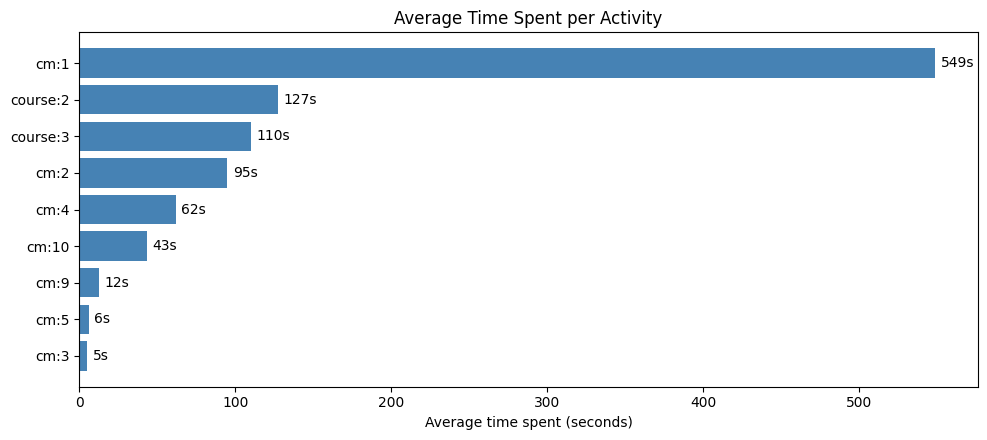

In [105]:
fig, ax = plt.subplots(figsize=(10, max(4, len(avg_time) * 0.5)))
bars = ax.barh(avg_time["label"], avg_time["avg_seconds"], color="steelblue")
ax.bar_label(bars, labels=[f"{v:.0f}s" for v in avg_time["avg_seconds"]], padding=4)
ax.set_xlabel("Average time spent (seconds)")
ax.set_title("Average Time Spent per Activity")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 3. Navigation Sequences (Learner Paths)

We reconstruct each learner's full navigation path and find the most common
two-step transitions.

In [106]:
# Build the ordered sequence of pages visited per user
sequences = (
    df.sort_values(["userid", "timecreated"])
    .groupby("userid")["label"]
    .apply(list)
    .reset_index()
)
sequences.columns = ["userid", "path"]
sequences["path_str"] = sequences["path"].apply(lambda p: " → ".join(p))
sequences[["userid", "path_str"]]

,userid,path_str
0,2,course:2 → course:2 → cm:1 → course:2 → cm:1 →...


In [107]:
# Extract all two-step transitions across all users
def bigrams(seq):
    return [(seq[i], seq[i + 1]) for i in range(len(seq) - 1)]

all_transitions = []
for path in sequences["path"]:
    all_transitions.extend(bigrams(path))

top_transitions = pd.DataFrame(
    Counter(all_transitions).most_common(10),
    columns=["transition", "count"]
)
top_transitions["transition"] = top_transitions["transition"].apply(
    lambda t: f"{t[0]}  →  {t[1]}"
)
top_transitions

,transition,count
0,course:2 → course:2,34
1,cm:4 → cm:4,31
2,course:3 → course:3,17
3,course:2 → cm:4,14
4,cm:4 → course:2,14
5,cm:10 → cm:10,12
6,course:2 → cm:2,11
7,course:3 → cm:10,9
8,cm:2 → cm:2,9
9,course:3 → cm:9,9


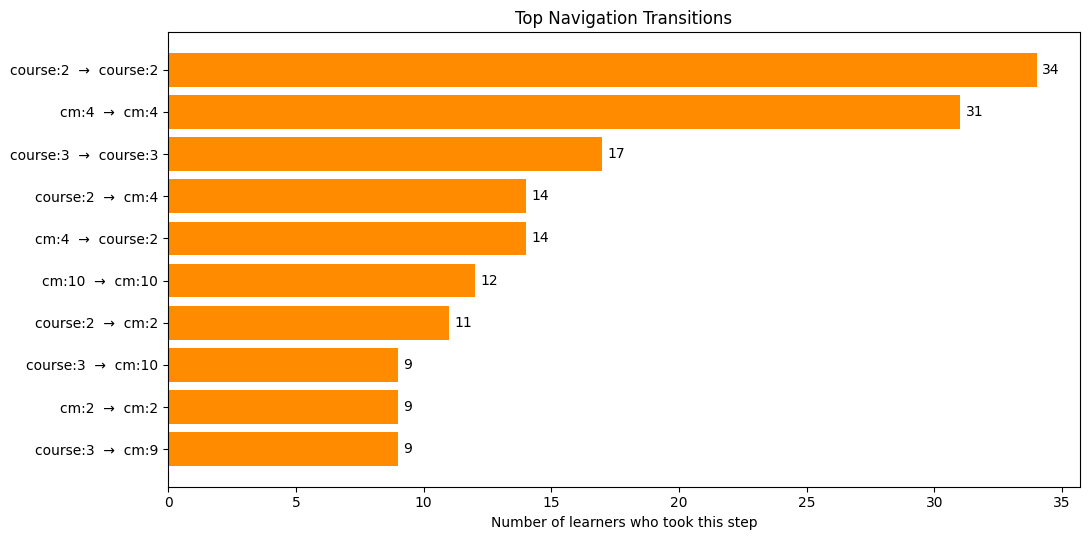

In [108]:
fig, ax = plt.subplots(figsize=(11, max(4, len(top_transitions) * 0.55)))
bars = ax.barh(top_transitions["transition"], top_transitions["count"], color="darkorange")
ax.bar_label(bars, padding=4)
ax.set_xlabel("Number of learners who took this step")
ax.set_title("Top Navigation Transitions")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Per-User Summary

A high-level view of each learner's engagement: how many pages they visited,
how long they spent in total, and how many unique activities they explored.

In [109]:
summary = (
    df.groupby("userid")
    .agg(
        total_events       = ("id",          "count"),
        unique_activities  = ("label",        "nunique"),
        total_time_seconds = ("timespent",    "sum"),
        first_seen         = ("datetime",     "min"),
        last_seen          = ("datetime",     "max"),
    )
    .reset_index()
)
summary["total_time_minutes"]    = (summary["total_time_seconds"] / 60).round(2)
summary["session_span_minutes"]  = (
    (summary["last_seen"] - summary["first_seen"]).dt.total_seconds() / 60
).round(2)
summary

,userid,total_events,unique_activities,total_time_seconds,first_seen,last_seen,total_time_minutes,session_span_minutes
0,2,228,10,20086,2026-03-03 21:40:07,2026-05-25 21:40:16,334.77,119520.15


## 5. Quiz Pass vs File Time (Same Section)

This section lets you select `courseid` and `sectionid` first.
Then it finds file and quiz activities in that section, detects students who passed the selected quiz,
and plots time spent by those passers on section file/quiz activities.

In [114]:
import os
import json
import requests
import pandas as pd

try:
    from dotenv import load_dotenv, find_dotenv
    load_dotenv(find_dotenv(usecwd=True), override=True)
except ImportError:
    pass

MOODLE_URL = os.getenv("MOODLE_URL") or globals().get("MOODLE_URL") or "http://localhost:8081"
TOKEN = os.getenv("MOODLE_TOKEN") or globals().get("TOKEN")
if not TOKEN:
    raise ValueError("MOODLE_TOKEN not set. Run the config cell first or add MOODLE_TOKEN to the .env file in the project root.")

# Type the IDs you want here, then run this cell and the chart cell below.
# Use the table printed by this cell to choose quiz/file cmid values.
ANALYSIS_COURSEID = 3
ANALYSIS_SECTIONID = 1
ANALYSIS_QUIZ_ITEMID = 10
ANALYSIS_FILE_ITEMID = 9


def ws_call_controls(wsfunction, **kwargs):
    params = {
        "wstoken": TOKEN,
        "wsfunction": wsfunction,
        "moodlewsrestformat": "json",
    }
    params.update(kwargs)
    resp = requests.get(f"{MOODLE_URL}/webservice/rest/server.php", params=params)
    resp.raise_for_status()
    data = resp.json()
    if isinstance(data, dict) and "exception" in data:
        raise RuntimeError(f"{wsfunction} failed: {data.get('message', data)}")
    return data


def module_quiz_close_time(module):
    for date in module.get("dates", []) or []:
        if date.get("dataid") == "timeclose" and int(date.get("timestamp", 0)) > 0:
            return int(date["timestamp"])
    customdata = module.get("customdata")
    if customdata:
        try:
            parsed = json.loads(customdata)
            if isinstance(parsed, str):
                parsed = json.loads(parsed)
            if isinstance(parsed, dict):
                return int(parsed.get("timeclose") or 0)
        except (TypeError, ValueError, json.JSONDecodeError):
            return 0
    return 0


def get_trajectories(courseid=0, userid=0, since=0):
    return ws_call_controls(
        "local_nextclicks_get_trajectories",
        courseid=courseid,
        userid=userid,
        since=since,
    )

print("Fetching trajectory data...")
raw = get_trajectories()
df = pd.DataFrame(raw)
if df.empty:
    raise ValueError("No trajectory data available yet.")
df["datetime"] = pd.to_datetime(df["timecreated"], unit="s")
df["label"] = df["itemtype"].astype(str) + ":" + df["itemid"].astype(str)

course_options = sorted(df["courseid"].astype(int).unique().tolist())
print("Available courses with trajectory data:")
for courseid in course_options:
    print(f"  courseid={courseid}")

if ANALYSIS_COURSEID not in course_options:
    raise ValueError(f"ANALYSIS_COURSEID must be one of {course_options}; got {ANALYSIS_COURSEID}")

contents = ws_call_controls("core_course_get_contents", courseid=ANALYSIS_COURSEID)
rows = []
for section in contents:
    section_number = int(section.get("section", 0))
    section_id = int(section.get("id", 0))
    section_name = section.get("name") or f"Section {section_number}"
    for module in section.get("modules", []):
        if module.get("modname") in {"quiz", "resource", "file"}:
            rows.append({
                "section": section_number,
                "section_record_id": section_id,
                "section_name": section_name,
                "modtype": module.get("modname"),
                "cmid": int(module.get("id", 0)),
                "name": module.get("name"),
                "quiz_timeclose": module_quiz_close_time(module) if module.get("modname") == "quiz" else 0,
            })

if not rows:
    raise ValueError(f"Course {ANALYSIS_COURSEID} has no quiz or file/resource modules visible to this token.")

available_df = pd.DataFrame(rows)
display(available_df)

section_numbers = set(available_df["section"].astype(int))
section_record_ids = set(available_df["section_record_id"].astype(int))
if ANALYSIS_SECTIONID in section_record_ids and ANALYSIS_SECTIONID not in section_numbers:
    selected_sectionnum = int(available_df.loc[available_df["section_record_id"] == ANALYSIS_SECTIONID, "section"].iloc[0])
else:
    selected_sectionnum = ANALYSIS_SECTIONID

section_df = available_df[available_df["section"].astype(int) == int(selected_sectionnum)]
quiz_options = sorted(section_df.loc[section_df["modtype"] == "quiz", "cmid"].astype(int).tolist())
file_options = sorted(section_df.loc[section_df["modtype"].isin(["resource", "file"]), "cmid"].astype(int).tolist())

if not quiz_options:
    raise ValueError(f"No quiz found in section {selected_sectionnum}. Check the table above.")
if not file_options:
    raise ValueError(f"No file/resource found in section {selected_sectionnum}. Check the table above.")
if ANALYSIS_QUIZ_ITEMID not in quiz_options:
    raise ValueError(f"ANALYSIS_QUIZ_ITEMID must be one of {quiz_options}; got {ANALYSIS_QUIZ_ITEMID}")
if ANALYSIS_FILE_ITEMID not in file_options:
    raise ValueError(f"ANALYSIS_FILE_ITEMID must be one of {file_options}; got {ANALYSIS_FILE_ITEMID}")

print(
    f"Active selection -> courseid={ANALYSIS_COURSEID}, "
    f"sectionid={ANALYSIS_SECTIONID}, "
    f"quiz_itemid={ANALYSIS_QUIZ_ITEMID}, "
    f"file_itemid={ANALYSIS_FILE_ITEMID}"
)
print("Now run the chart cell directly below this one.")


Fetching trajectory data...
Available courses with trajectory data:
  courseid=2
  courseid=3


,section,section_record_id,section_name,modtype,cmid,name,quiz_timeclose
0,1,8,1,resource,9,1.1,0
1,1,8,1,quiz,10,1.2,0


Active selection -> courseid=3, sectionid=1, quiz_itemid=10, file_itemid=9
Now run the chart cell directly below this one.


In [116]:
# Compatibility helper for older chart cells.
# Run this before the Analysis 5 bar chart cell if it says get_trajectories is not defined.
def get_trajectories(courseid=0, userid=0, since=0):
    return ws_call_controls(
        "local_nextclicks_get_trajectories",
        courseid=courseid,
        userid=userid,
        since=since,
    )

print("get_trajectories helper is ready.")


get_trajectories helper is ready.


Fetching fresh course trajectory data...


,group,students,avg_file_time_seconds
0,Passed,0,0.0
1,Failed,1,117.0


Note: gradepass not returned by API for at least one user; fallback rule used (grade > 0 => Passed).
Selected file: cm:9 (1.1)
Selected quiz: cm:10 (1.2)
Quiz has no close deadline; counting each student's file time until their final allowed attempt is finished. Attempt limit: 1
Student cutoffs: {2: 1779577846}


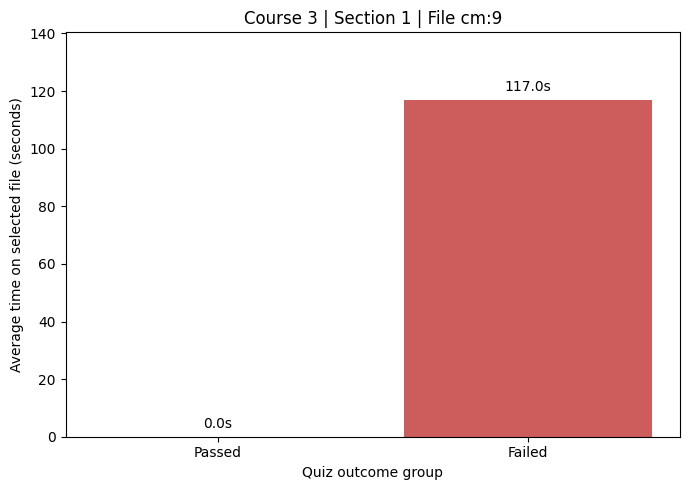

In [112]:
import os
import json
import requests
import pandas as pd
import matplotlib.pyplot as plt

try:
    from dotenv import load_dotenv, find_dotenv
    load_dotenv(find_dotenv(usecwd=True), override=True)
except ImportError:
    pass

MOODLE_URL = os.getenv("MOODLE_URL") or globals().get("MOODLE_URL") or "http://localhost:8081"
TOKEN = os.getenv("MOODLE_TOKEN") or globals().get("TOKEN")
if not TOKEN:
    raise ValueError("MOODLE_TOKEN not set. Run the config cell first or add MOODLE_TOKEN to .env.")

required = ["ANALYSIS_COURSEID", "ANALYSIS_SECTIONID", "ANALYSIS_QUIZ_ITEMID", "ANALYSIS_FILE_ITEMID"]
missing = [name for name in required if name not in globals()]
if missing:
    raise ValueError(f"Run the Analysis 5 selection cell first. Missing: {missing}")


def flatten_params(params):
    flat = {}
    for key, value in params.items():
        if isinstance(value, (list, tuple)):
            for index, item in enumerate(value):
                flat[f"{key}[{index}]"] = item
        else:
            flat[key] = value
    return flat


def ws_call(wsfunction, **kwargs):
    params = {
        "wstoken": TOKEN,
        "wsfunction": wsfunction,
        "moodlewsrestformat": "json",
    }
    params.update(flatten_params(kwargs))
    resp = requests.get(f"{MOODLE_URL}/webservice/rest/server.php", params=params)
    resp.raise_for_status()
    data = resp.json()
    if isinstance(data, dict) and "exception" in data:
        raise RuntimeError(f"{wsfunction} failed: {data.get('message', data)}")
    return data


def get_trajectories(courseid=0, userid=0, since=0):
    return ws_call(
        "local_nextclicks_get_trajectories",
        courseid=courseid,
        userid=userid,
        since=since,
    )


def to_float(value):
    try:
        return float(value)
    except (TypeError, ValueError):
        return None


def get_quiz_close_time(quiz_module):
    for date in quiz_module.get("dates", []) or []:
        if date.get("dataid") == "timeclose" and int(date.get("timestamp", 0)) > 0:
            return int(date["timestamp"])
    customdata = quiz_module.get("customdata")
    if customdata:
        try:
            parsed = json.loads(customdata)
            if isinstance(parsed, str):
                parsed = json.loads(parsed)
            if isinstance(parsed, dict):
                return int(parsed.get("timeclose") or 0)
        except (TypeError, ValueError, json.JSONDecodeError):
            return 0
    return 0


def get_selected_quiz_attempt_limit(courseid, quiz_instance):
    response = ws_call("mod_quiz_get_quizzes_by_courses", courseids=[courseid])
    for quiz in response.get("quizzes", []):
        if int(quiz.get("id", 0)) == int(quiz_instance):
            return int(quiz.get("attempts") or 0)
    return 0


def get_user_attempt_cutoff(quiz_instance, userid, attempt_limit):
    if attempt_limit <= 0:
        return 0
    response = ws_call(
        "mod_quiz_get_user_attempts",
        quizid=quiz_instance,
        userid=userid,
        status="all",
        includepreviews=0,
    )
    attempts = [a for a in response.get("attempts", []) if int(a.get("preview", 0)) == 0]
    finished = [a for a in attempts if a.get("state") == "finished" and int(a.get("timefinish") or 0) > 0]
    if len(finished) < attempt_limit:
        return 0
    return max(int(a.get("timefinish") or 0) for a in finished)

print("Fetching fresh course trajectory data...")
course_df = pd.DataFrame(get_trajectories(courseid=ANALYSIS_COURSEID))
if course_df.empty:
    raise ValueError("No trajectory events found for this course yet.")
course_df["datetime"] = pd.to_datetime(course_df["timecreated"], unit="s")

contents = ws_call("core_course_get_contents", courseid=ANALYSIS_COURSEID)
module_by_cmid = {}
for section in contents:
    secnum = int(section.get("section", 0))
    secid = int(section.get("id", 0))
    for mod in section.get("modules", []):
        cmid = int(mod.get("id", 0))
        module_by_cmid[cmid] = {
            "cmid": cmid,
            "name": mod.get("name", f"cm:{cmid}"),
            "modname": mod.get("modname", ""),
            "instance": int(mod.get("instance", 0)),
            "section": secnum,
            "sectionid": secid,
            "customdata": mod.get("customdata"),
            "dates": mod.get("dates", []),
        }

section_numbers = {m["section"] for m in module_by_cmid.values()}
section_ids = {m["sectionid"] for m in module_by_cmid.values()}
if ANALYSIS_SECTIONID in section_numbers:
    selected_sectionnum = ANALYSIS_SECTIONID
elif ANALYSIS_SECTIONID in section_ids:
    selected_sectionnum = next(m["section"] for m in module_by_cmid.values() if m["sectionid"] == ANALYSIS_SECTIONID)
else:
    selected_sectionnum = ANALYSIS_SECTIONID

selected_quiz = module_by_cmid.get(int(ANALYSIS_QUIZ_ITEMID))
selected_file = module_by_cmid.get(int(ANALYSIS_FILE_ITEMID))
if selected_quiz is None or selected_quiz.get("modname") != "quiz" or selected_quiz.get("section") != selected_sectionnum:
    raise ValueError("Selected quiz item is not a quiz in the selected section. Re-run the selection cell and check the table.")
if selected_file is None or selected_file.get("modname") not in {"resource", "file"} or selected_file.get("section") != selected_sectionnum:
    raise ValueError("Selected file item is not a file/resource in the selected section. Re-run the selection cell and check the table.")

quiz_instance = int(selected_quiz["instance"])
quiz_close_time = get_quiz_close_time(selected_quiz)
quiz_attempt_limit = get_selected_quiz_attempt_limit(ANALYSIS_COURSEID, quiz_instance)

candidate_users = sorted(course_df["userid"].astype(int).unique().tolist())
user_cutoffs = {}
for uid in candidate_users:
    if quiz_close_time > 0:
        user_cutoffs[uid] = quiz_close_time
    elif quiz_attempt_limit > 0:
        cutoff = get_user_attempt_cutoff(quiz_instance, uid, quiz_attempt_limit)
        if cutoff > 0:
            user_cutoffs[uid] = cutoff

passers = []
failers = []
skipped_without_grade = []
used_gradepass_fallback = False

for uid in candidate_users:
    grades = ws_call("gradereport_user_get_grade_items", courseid=ANALYSIS_COURSEID, userid=uid)
    usergrades = grades.get("usergrades", []) if isinstance(grades, dict) else []
    quiz_grade_item = None
    for ug in usergrades:
        for gi in ug.get("gradeitems", []):
            if gi.get("itemmodule") == "quiz" and int(gi.get("iteminstance", 0)) == quiz_instance:
                quiz_grade_item = gi
                break
        if quiz_grade_item is not None:
            break

    if quiz_grade_item is None:
        skipped_without_grade.append(uid)
        continue

    grade_raw = to_float(quiz_grade_item.get("graderaw"))
    grade_pass = to_float(quiz_grade_item.get("gradepass"))
    if grade_raw is None:
        skipped_without_grade.append(uid)
        continue
    if grade_pass is None:
        used_gradepass_fallback = True
        if grade_raw > 0:
            passers.append(uid)
        else:
            failers.append(uid)
        continue
    if grade_raw >= grade_pass:
        passers.append(uid)
    else:
        failers.append(uid)

file_cmid = int(selected_file["cmid"])
file_name = selected_file["name"]
file_df = course_df[(course_df["itemtype"] == "cm") & (course_df["itemid"].astype(int) == file_cmid)].copy()


def file_time_for_user(userid):
    cutoff = int(user_cutoffs.get(int(userid), 0))
    dwell_args = {"courseid": ANALYSIS_COURSEID, "cmid": file_cmid, "userid": int(userid)}
    if cutoff > 0:
        dwell_args["until"] = cutoff
    dwell_rows = ws_call("local_nextclicks_get_file_dwell", **dwell_args)
    if dwell_rows:
        return float(dwell_rows[0].get("dwellseconds") or 0.0)

    user_file_df = file_df[file_df["userid"].astype(int) == int(userid)].copy()
    if cutoff > 0:
        user_file_df = user_file_df[user_file_df["timecreated"].astype(int) <= cutoff]
    if user_file_df.empty:
        return 0.0
    return float(user_file_df["timespent"].sum())


def avg_file_time_for_users(user_ids):
    if not user_ids:
        return 0.0
    values = [file_time_for_user(uid) for uid in user_ids]
    return float(sum(values) / len(values))

result = pd.DataFrame({
    "group": ["Passed", "Failed"],
    "students": [len(passers), len(failers)],
    "avg_file_time_seconds": [avg_file_time_for_users(passers), avg_file_time_for_users(failers)],
})
display(result)

if used_gradepass_fallback:
    print("Note: gradepass not returned by API for at least one user; fallback rule used (grade > 0 => Passed).")
if skipped_without_grade:
    print(f"Skipped users without a grade for this quiz: {skipped_without_grade}")
print(f"Selected file: cm:{file_cmid} ({file_name})")
print(f"Selected quiz: cm:{selected_quiz['cmid']} ({selected_quiz['name']})")
if quiz_close_time > 0:
    print(f"Counting each student's file time only up to quiz close timestamp: {quiz_close_time}")
elif quiz_attempt_limit > 0:
    print(f"Quiz has no close deadline; counting each student's file time until their final allowed attempt is finished. Attempt limit: {quiz_attempt_limit}")
    print(f"Student cutoffs: {user_cutoffs if user_cutoffs else 'none reached yet'}")
else:
    print("Selected quiz has no close deadline and unlimited attempts; counting all file time.")

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(result["group"], result["avg_file_time_seconds"], color=["seagreen", "indianred"])
ax.bar_label(bars, labels=[f"{v:.1f}s" for v in result["avg_file_time_seconds"]], padding=4)
ax.set_xlabel("Quiz outcome group")
ax.set_ylabel("Average time on selected file (seconds)")
ax.set_title(f"Course {ANALYSIS_COURSEID} | Section {selected_sectionnum} | File cm:{file_cmid}")
upper = max(result["avg_file_time_seconds"].max(), 1.0)
ax.set_ylim(0, upper * 1.2)
plt.tight_layout()
plt.show()


In [113]:
# replace with your selected file cmid if known
courseid = 2
file_cmid = 2

dwell = ws_call("local_nextclicks_get_file_dwell", courseid=courseid, cmid=file_cmid)
print("dwell rows:", len(dwell))
dwell[:10]


dwell rows: 0


[]